# 3. Clustering

We look for groups of games with similar profiles in terms of complexity,
recommended age, expected duration and popularity. Four numerical attributes
are used: `AvgGameweight`, `ComAgeRec`, `ComAvgPlaytime_log` (the log version
tames the right-skewed durations) and `PopularityScore`. The same MinMax-scaled
representation feeds K-Means, DBSCAN and hierarchical clustering, so the
results are directly comparable. Category flags are only used afterwards to
interpret the clusters, never to build them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, BisectingKMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram

df = pd.read_csv("../data/df_clean2.2.csv")
features = ["AvgGameweight", "ComAgeRec", "ComAvgPlaytime_log", "PopularityScore"]
X = MinMaxScaler().fit_transform(df[features])
X.shape

(21925, 4)

## 3.1 K-Means

K-Means++ initialization, `n_init=10`, evaluated for k = 2..15 with SSE (elbow)
and mean Silhouette.

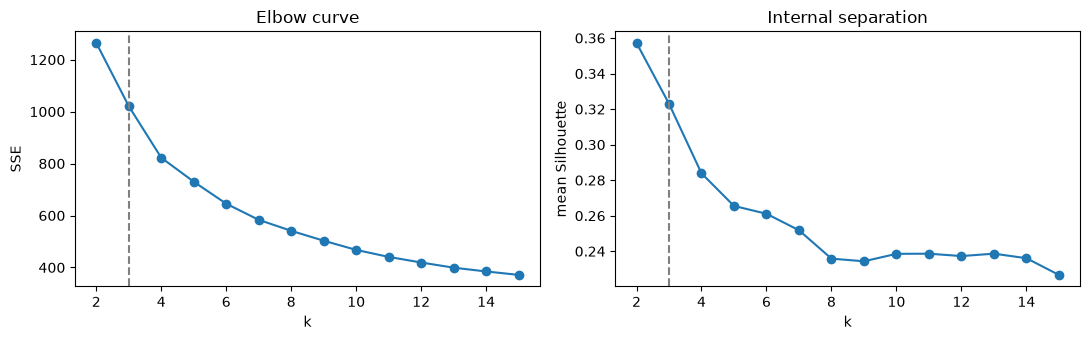

,k,SSE,silhouette
0,2,1264.45,0.357
1,3,1020.97,0.323
2,4,822.50,0.284
3,5,730.26,0.266
4,6,645.46,0.261
5,7,583.41,0.252
6,8,541.11,0.236
7,9,502.94,0.234
8,10,467.70,0.239
9,11,440.68,0.239


In [2]:
ks = range(2, 16)
sse, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, max_iter=300,
                random_state=42).fit(X)
    sse.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(ks, sse, "o-")
axes[0].set(xlabel="k", ylabel="SSE", title="Elbow curve")
axes[1].plot(ks, sil, "o-")
axes[1].set(xlabel="k", ylabel="mean Silhouette", title="Internal separation")
for ax in axes:
    ax.axvline(3, ls="--", c="gray")
plt.tight_layout()
plt.show()

pd.DataFrame({"k": ks, "SSE": np.round(sse, 2), "silhouette": np.round(sil, 3)})

k = 2 maximizes the Silhouette but the partition is very coarse. k = 3 keeps an
acceptable separation while adding a distinct, interpretable profile, and for
k >= 4 the Silhouette drops with only incremental SSE gains, so we keep k = 3.

In [3]:
km3 = KMeans(n_clusters=3, init="k-means++", n_init=10, max_iter=300,
             random_state=42).fit(X)
df["KMeans"] = km3.labels_
print(f"SSE = {km3.inertia_:.2f}, silhouette = {silhouette_score(X, km3.labels_):.3f}")

profile = df.groupby("KMeans").agg(
    games=("KMeans", "size"),
    complexity=("AvgGameweight", "mean"),
    age_rec=("ComAgeRec", "mean"),
    playtime_median=("ComAvgPlaytime", "median"),
    popularity=("PopularityScore", "mean")).round(3)
profile["games %"] = (profile["games"] / len(df) * 100).round(1)
profile

SSE = 1020.97, silhouette = 0.323


,games,complexity,age_rec,playtime_median,popularity,games %
KMeans,,,,,,
0,11133,1.583,8.265,30.0,0.278,50.8
1,6536,2.969,13.076,90.0,0.331,29.8
2,4256,2.260,9.944,45.0,0.557,19.4


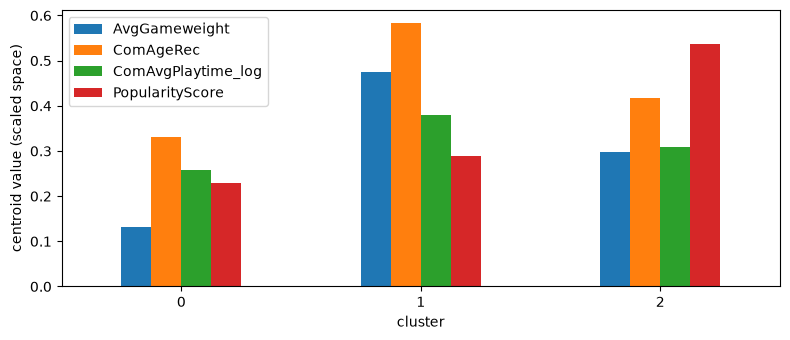

In [4]:
centroids = pd.DataFrame(km3.cluster_centers_, columns=features)
centroids.plot.bar(figsize=(8, 3.5), rot=0)
plt.ylabel("centroid value (scaled space)")
plt.xlabel("cluster")
plt.tight_layout()
plt.show()

The three profiles read naturally: **C-low** accessible/short games (about half
of the dataset, low complexity and age), a smaller cluster of **popular
mid-complexity** games with the highest popularity score, and **complex/longer**
games with the highest recommended age. Playtime is reported as median minutes
because durations stay asymmetric even after the log transform.

## 3.2 Bisecting K-Means (optional comparison)

In [5]:
bkm = BisectingKMeans(n_clusters=3, random_state=42).fit(X)
print("sizes:", np.bincount(bkm.labels_),
      "| silhouette:", round(silhouette_score(X, bkm.labels_), 3))

sizes: [6348 6831 8746] | silhouette: 0.213


The bisecting variant yields more balanced groups but a clearly lower
Silhouette than standard K-Means, so it is not retained.

## 3.3 DBSCAN

Neighbourhood sizes around the data dimensionality (MinPts = 6 and 8) are
explored; candidate radii are read off the sorted k-distance curve and then
compared with a small grid. Silhouette is computed on non-noise points only.

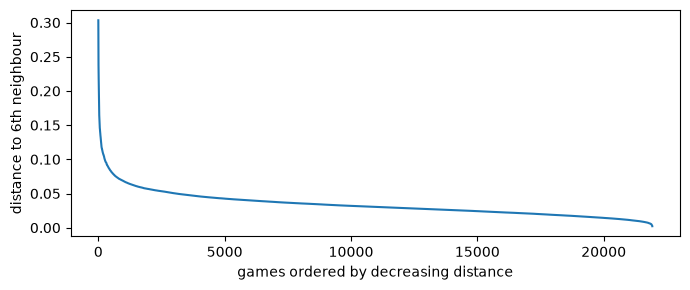

In [6]:
dist6 = NearestNeighbors(n_neighbors=6).fit(X).kneighbors(X)[0][:, -1]
plt.figure(figsize=(7, 3))
plt.plot(np.sort(dist6)[::-1])
plt.xlabel("games ordered by decreasing distance")
plt.ylabel("distance to 6th neighbour")
plt.tight_layout()
plt.show()

In [7]:
rows = []
for min_pts in (6, 8):
    for eps in (0.05, 0.06, 0.065, 0.07, 0.075, 0.08, 0.09, 0.10, 0.12):
        labels = DBSCAN(eps=eps, min_samples=min_pts).fit_predict(X)
        n_noise = (labels == -1).sum()
        sizes = np.bincount(labels[labels >= 0]) if (labels >= 0).any() else []
        n_clusters = len(sizes)
        core = labels >= 0
        s = silhouette_score(X[core], labels[core]) if n_clusters > 1 else np.nan
        rows.append([min_pts, eps, n_clusters, n_noise / len(X),
                     max(sizes) / len(X) if n_clusters else np.nan, s,
                     sorted(sizes, reverse=True)[:4]])
dbscan_grid = pd.DataFrame(rows, columns=["MinPts", "eps", "clusters", "noise %",
                                          "largest %", "silhouette", "sizes"])
dbscan_grid.round(3)

,MinPts,eps,clusters,noise %,largest %,silhouette,sizes
0,6,0.050,13,0.075,0.921,-0.235,"[20201, 11, 10, 9]"
1,6,0.060,8,0.036,0.962,-0.047,"[21097, 10, 7, 6]"
2,6,0.065,6,0.027,0.971,-0.016,"[21291, 10, 10, 9]"
3,6,0.070,6,0.020,0.979,-0.041,"[21465, 11, 5, 4]"
4,6,0.075,2,0.015,0.985,0.440,"[21587, 11]"
5,6,0.080,1,0.012,0.988,NaN,[21658]
6,6,0.090,2,0.008,0.992,0.417,"[21748, 6]"
7,6,0.100,2,0.005,0.994,0.397,"[21797, 16]"
8,6,0.120,1,0.003,0.997,NaN,[21868]
9,8,0.050,9,0.096,0.896,-0.098,"[19648, 72, 34, 17]"


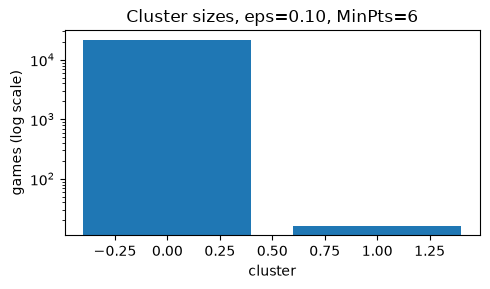

sizes: [21797    16] | noise: 112


In [8]:
labels = DBSCAN(eps=0.10, min_samples=6).fit_predict(X)
sizes = np.bincount(labels[labels >= 0])
plt.figure(figsize=(5, 3))
plt.bar(range(len(sizes)), sizes, log=True)
plt.xlabel("cluster")
plt.ylabel("games (log scale)")
plt.title("Cluster sizes, eps=0.10, MinPts=6")
plt.tight_layout()
plt.show()
print("sizes:", sizes, "| noise:", (labels == -1).sum())

Every configuration is dominated by one macro-cluster containing more than 96%
of the games, with the remaining clusters counting a handful of points. The
best Silhouette (MinPts=8, eps=0.065) corresponds to a degenerate two-cluster
solution. In this feature space games are spread along continuous gradients
rather than in separated dense islands, so DBSCAN does not provide a useful
segmentation.

## 3.4 Hierarchical clustering

Complete and Ward linkage with Euclidean distance. Dendrograms are drawn on a
reproducible sample of 800 games for readability; scores and cluster sizes are
computed on the whole dataset.

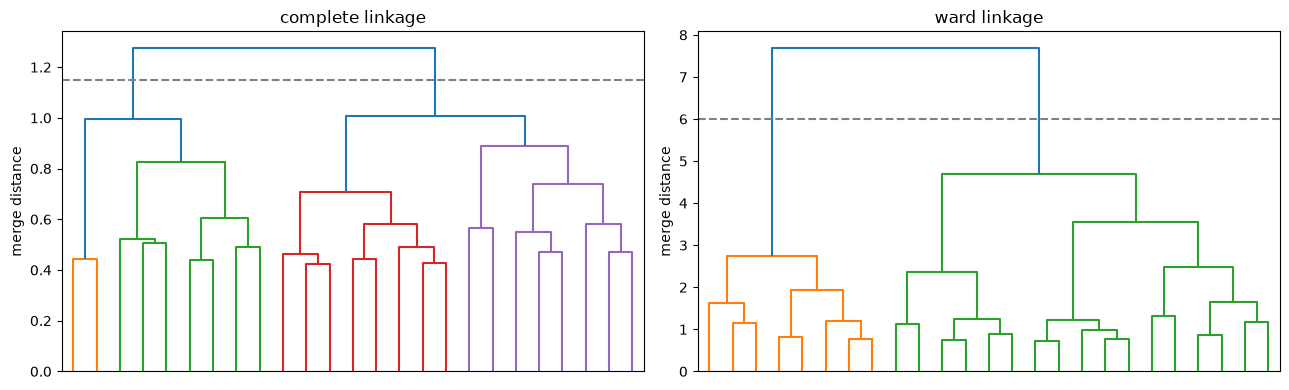

In [9]:
sample = df.sample(800, random_state=42).index
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, method, cut in [(axes[0], "complete", 1.15), (axes[1], "ward", 6)]:
    Z = linkage(X[sample], method=method)
    dendrogram(Z, truncate_mode="lastp", p=25, no_labels=True, ax=ax)
    ax.axhline(cut, ls="--", c="gray")
    ax.set_title(f"{method} linkage")
    ax.set_ylabel("merge distance")
plt.tight_layout()
plt.show()

In [10]:
rows = []
lab = AgglomerativeClustering(n_clusters=None, distance_threshold=1.15,
                              linkage="complete").fit_predict(X)
rows.append(["complete, threshold=1.15", lab.max() + 1,
             silhouette_score(X, lab), sorted(np.bincount(lab), reverse=True)])
for k in (2, 3, 4, 5):
    lab = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)
    rows.append([f"ward, k={k}", k, silhouette_score(X, lab),
                 sorted(np.bincount(lab), reverse=True)])
hier = pd.DataFrame(rows, columns=["configuration", "clusters", "silhouette", "sizes"])
hier.round(3)

,configuration,clusters,silhouette,sizes
0,"complete, threshold=1.15",5,0.208,"[15538, 3800, 1922, 387, 278]"
1,"ward, k=2",2,0.308,"[14212, 7713]"
2,"ward, k=3",3,0.290,"[14212, 4653, 3060]"
3,"ward, k=4",4,0.224,"[9284, 4928, 4653, 3060]"
4,"ward, k=5",5,0.212,"[9284, 4928, 3060, 2916, 1737]"


Ward with k = 2 gives the best hierarchical Silhouette but, as for K-Means,
the split is coarse. Ward with k = 3 produces three substantial groups that
mirror the K-Means profiles with weaker separation, and is kept as the most
useful hierarchical comparison.

## 3.5 Final comparison

In [11]:
summary = pd.DataFrame([
    ["K-Means", "k=3", round(silhouette_score(X, km3.labels_), 3),
     sorted(np.bincount(km3.labels_), reverse=True)],
    ["Bisecting K-Means", "k=3", round(silhouette_score(X, bkm.labels_), 3),
     sorted(np.bincount(bkm.labels_), reverse=True)],
    ["DBSCAN", "eps=0.10, MinPts=6",
     dbscan_grid.query("MinPts == 6 and eps == 0.10")["silhouette"].round(3).item(),
     "one macro-cluster + noise"],
    ["Hierarchical", "ward, k=3", hier.loc[2, "silhouette"].round(3),
     hier.loc[2, "sizes"]],
], columns=["method", "setting", "silhouette", "cluster sizes"])
summary

,method,setting,silhouette,cluster sizes
0,K-Means,k=3,0.323,"[11133, 6536, 4256]"
1,Bisecting K-Means,k=3,0.213,"[8746, 6831, 6348]"
2,DBSCAN,"eps=0.10, MinPts=6",0.397,one macro-cluster + noise
3,Hierarchical,"ward, k=3",0.290,"[14212, 4653, 3060]"


K-Means with k = 3 is the best compromise between separation and an
interpretable multi-profile segmentation: it does not beat the two-cluster
optimum on Silhouette, but it exposes three readable profiles (accessible
short games, popular mid-complexity games, complex longer games). DBSCAN shows
that no island-like density structure exists in these variables, and Ward
confirms the same broad profiles with lower separation: complexity, age,
duration and popularity describe board games through continuous gradients
rather than sharply separated segments.